# Task 2 — DINOv2-small Feature Extraction
## Dataset: Oxford Pets

This notebook applies the **facebook/dinov2-small** vision transformer to extract feature
representations for the Oxford Pets dataset. The extracted embeddings are further analysed
using PCA, t-SNE, K-Means clustering, and a 70/10/20 train-validation-test split to evaluate
classification performance.

This stage focuses on:

- loading and preprocessing the Oxford Pets dataset
- extracting DINOv2 feature embeddings
- applying PCA and t-SNE for dimensionality reduction
- evaluating structure using K-Means clustering
- training a classifier to assess discriminative performance

## Importing Required Libraries

This cell imports all dependencies necessary for image preprocessing, feature extraction,
dimensionality reduction, clustering, and evaluation. These include:

- PyTorch and Torchvision for dataset handling
- scikit-learn for PCA, t-SNE, clustering, and classification metrics
- Transformers for loading the pretrained DINOv2-small image model
- Matplotlib for visualisation


In [10]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, davies_bouldin_score

import matplotlib.pyplot as plt
from transformers import AutoImageProcessor, AutoModel
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True


## Dataset Path, Image Transformations, and Subset Creation

The Oxford Pets dataset directory is specified, and a set of image transformations is applied,
including resizing each image to `(224, 224)` and converting it into a PyTorch tensor suitable
for DINOv2-small.

The dataset is loaded using `ImageFolder`.
Because this task focuses on feature extraction rather than full fine-grained classification,
a subset of **3000 images** is selected for efficient processing.

A `DataLoader` is then created to iterate through the selected subset in batches, enabling
efficient feature extraction using the DINOv2 model.

In [11]:
data_path = "data/oxfordpets"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

ds = datasets.ImageFolder(data_path, transform=transform)

# Balanced subset for Cats vs Dogs, subset for Oxford Pets
if "Oxford Pets" == "Cats vs Dogs":
    samples = ds.samples
    cats = [s for s in samples if "Cat" in s[0]][:1000]
    dogs = [s for s in samples if "Dog" in s[0]][:1000]
    ds.samples = cats + dogs
else:
    ds.samples = ds.samples[:3000]

dl = DataLoader(ds, batch_size=32, shuffle=False)

print("Classes:", ds.classes)
print("Total samples:", len(ds.samples))


Classes: ['Abyssinian', 'Bengal', 'Birman', 'Bombay', 'British', 'Egyptian', 'Maine', 'Persian', 'Ragdoll', 'Russian', 'Siamese', 'Sphynx', 'american', 'basset', 'beagle', 'boxer', 'chihuahua', 'english', 'german', 'great', 'havanese', 'japanese', 'keeshond', 'leonberger', 'miniature', 'newfoundland', 'pomeranian', 'pug', 'saint', 'samoyed', 'scottish', 'shiba', 'staffordshire', 'wheaten', 'yorkshire']
Total samples: 3000


## Device Setup and Loading DINOv2-small Model

The notebook automatically detects whether a CUDA-enabled GPU is available to accelerate
feature extraction. The pretrained **facebook/dinov2-small** model and its associated image
processor are loaded, and the model is placed in evaluation mode to ensure deterministic
outputs during inference.

In [12]:
device = "cuda" if torch.cuda.is_available() else "cpu"

processor = AutoImageProcessor.from_pretrained("facebook/dinov2-small")
model = AutoModel.from_pretrained("facebook/dinov2-small").to(device)
model.eval()

to_pil = transforms.ToPILImage()


## Feature Extraction Using DINOv2-small and Saving Feature Outputs

A feature extraction function is implemented to:

- convert batches of tensors into PIL images
- preprocess images using the DINOv2 image processor
- generate embeddings via a forward pass through DINOv2-small
- extract the **CLS token** from the final hidden state
- accumulate feature vectors and their corresponding labels

The function is executed on the Oxford Pets subset, producing a complete feature matrix of
CLS-token embeddings.

Outputs generated:

- `features.csv` — containing extracted CLS-token features
- printed feature matrix shape for verification

All outputs are stored inside the `output_oxfordpets/` directory for further analysis.

In [13]:
def extract_features(loader):
    all_feats, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            pil_images = [to_pil(img) for img in x]  # convert tensor -> PIL
            inputs = processor(images=pil_images, return_tensors="pt")
            inputs = {k: v.to(device) for k, v in inputs.items()}

            outputs = model(**inputs)
            cls_feats = outputs.last_hidden_state[:, 0, :]  # CLS token

            all_feats.append(cls_feats.cpu().numpy())
            all_labels.append(y.numpy())
    return np.vstack(all_feats), np.hstack(all_labels)

features, labels = extract_features(dl)

os.makedirs("output_oxfordpets", exist_ok=True)
pd.DataFrame(features).to_csv("output_oxfordpets/features.csv", index=False)

print("Feature matrix shape:", features.shape)


Feature matrix shape: (3000, 384)


## Creating Train, Validation, and Test Splits

A stratified split is applied to preserve class distribution.

Steps:

1. A 70/30 split separates training data from evaluation data.
2. The remaining 30% is divided into:
   - **Validation set (10%)**
   - **Test set (20%)**

Shapes of each split are printed to confirm correct partitioning.

In [14]:
X_train, X_temp, y_train, y_temp = train_test_split(
    features, labels, test_size=0.30, random_state=42, stratify=labels
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=2/3, random_state=42, stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


Train: (2100, 384)
Validation: (300, 384)
Test: (600, 384)


## Dimensionality Reduction Using PCA and t-SNE

Two complementary dimensionality reduction techniques are applied:

1. **PCA (50 Components)**
   PCA reduces the high-dimensional CLS-token embeddings into a compact representation while
   retaining the most important variance within the data.

2. **t-SNE (2D Projection)**
   t-SNE is applied on the PCA-reduced features to generate a two-dimensional visualisation
   that reveals the structure and separation of classes within the Oxford Pets dataset.

The generated t-SNE coordinates are saved to `output_oxfordpets/tsne.csv`, and a scatterplot
is produced to visualise the data distribution.

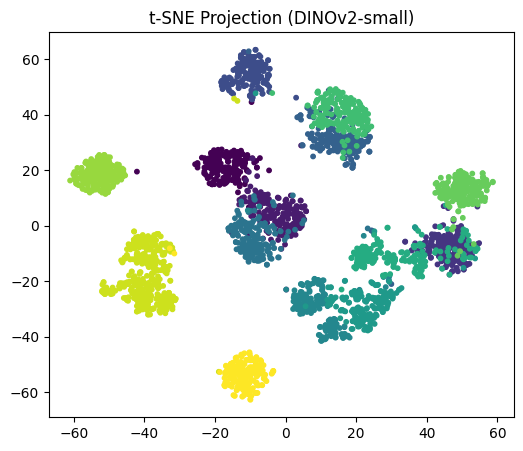

In [15]:
pca = PCA(n_components=50)
X_pca = pca.fit_transform(features)

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_pca)

pd.DataFrame(X_tsne).to_csv("output_oxfordpets/tsne.csv", index=False)

plt.figure(figsize=(6,5))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=labels, s=10)
plt.title("t-SNE Projection (DINOv2-small)")
plt.show()


## K-Means Clustering on PCA Features

K-Means clustering is applied using `k` equal to the number of classes present in the labels.
Cluster assignments are generated using the PCA-reduced representations, and the clustering
quality is evaluated using the Davies–Bouldin Index.

A lower DB index value indicates more compact and well-separated clusters.

In [16]:
k = len(np.unique(labels))
km = KMeans(n_clusters=k, random_state=42)
clusters = km.fit_predict(X_pca)

db_idx = davies_bouldin_score(X_pca, clusters)
print("Davies–Bouldin Index:", db_idx)


Davies–Bouldin Index: 2.0828695969330653


## Classification Using Logistic Regression

A Logistic Regression model is trained on the 70% training split and evaluated on the
validation and test sets.

Performance metrics include:

- Validation Accuracy
- Test Accuracy
- Full Classification Report
- Confusion Matrix visualisation

These results provide a quantitative assessment of how well the DINOv2-small embeddings
support supervised classification on the Oxford Pets dataset.

Validation Accuracy: 0.9466666666666667
Test Accuracy: 0.9733333333333334

Test Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.98        40
           1       0.95      0.95      0.95        40
           2       0.87      0.97      0.92        40
           3       1.00      0.97      0.99        40
           4       0.97      0.97      0.97        40
           5       0.97      0.95      0.96        40
           6       1.00      0.97      0.99        40
           7       1.00      1.00      1.00        40
           8       0.95      0.88      0.91        40
           9       0.95      0.97      0.96        40
          10       1.00      0.97      0.99        40
          11       1.00      1.00      1.00        40
          12       1.00      0.99      0.99        80
          13       1.00      1.00      1.00        40

    accuracy                           0.97       600
   macro avg       0.97      0.

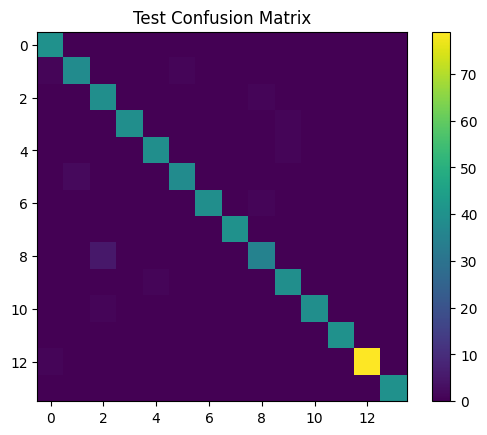

In [17]:
clf = LogisticRegression(max_iter=800)
clf.fit(X_train, y_train)

val_pred = clf.predict(X_val)
test_pred = clf.predict(X_test)

val_acc = accuracy_score(y_val, val_pred)
test_acc = accuracy_score(y_test, test_pred)

print("Validation Accuracy:", val_acc)
print("Test Accuracy:", test_acc)
print("\nTest Classification Report:")
print(classification_report(y_test, test_pred))

cm = confusion_matrix(y_test, test_pred)
plt.imshow(cm)
plt.title("Test Confusion Matrix")
plt.colorbar()
plt.show()


## Creating and Saving Model Performance Summary

A summary dictionary is created to consolidate key performance metrics, including:

- training, validation, and test set sizes
- validation and test accuracies
- Davies–Bouldin Index from clustering

The summary is stored in `summary.csv` within the `output_oxfordpets/` directory.
This file provides a concise overview of model performance and supports further reporting.

In [18]:
summary = {
    "train_size": len(X_train),
    "val_size": len(X_val),
    "test_size": len(X_test),
    "val_accuracy": val_acc,
    "test_accuracy": test_acc,
    "db_index": db_idx
}

pd.DataFrame([summary]).to_csv("output_oxfordpets/summary.csv", index=False)
print("Summary saved to output/summary.csv")


Summary saved to output/summary.csv
